In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install yfinance pandas numpy requests

In [18]:
TICKERS = [
    "AAPL",   # Tech
    "JPM",    # Financials
    "XOM",    # Energy
    "JNJ",    # Healthcare
    "PG",     # Consumer Staples
    "^GSPC"   # S&P 500 Index
]

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import time
from requests.exceptions import RequestException

START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
MAX_RETRIES = 5
SLEEP_BASE = 2  # exponential backoff base


def fetch_ticker_data(ticker):
    """Fetch historical data with retry + exponential backoff."""
    for attempt in range(MAX_RETRIES):
        try:
            print(f"Fetching {ticker} (Attempt {attempt+1})")
            data = yf.download(
                ticker,
                start=START_DATE,
                end=END_DATE,
                auto_adjust=False,   # Keep raw to handle adjustments ourselves
                progress=False
            )

            if data.empty:
                raise ValueError(f"No data returned for {ticker}")

            return data

        except (RequestException, ValueError) as e:
            wait = SLEEP_BASE ** attempt
            print(f"Error: {e}. Retrying in {wait}s...")
            time.sleep(wait)

    raise RuntimeError(f"Failed to fetch data for {ticker} after {MAX_RETRIES} attempts")


# Fetch all
raw_data = {ticker: fetch_ticker_data(ticker) for ticker in TICKERS}


Fetching AAPL (Attempt 1)
Fetching JPM (Attempt 1)
Fetching XOM (Attempt 1)
Fetching JNJ (Attempt 1)
Fetching PG (Attempt 1)
Fetching ^GSPC (Attempt 1)


In [20]:
def validate_adjustments(ticker, df):
    print(f"\nChecking corporate actions for {ticker}")
    
    splits = yf.Ticker(ticker).splits
    dividends = yf.Ticker(ticker).dividends

    print(f"Splits found: {len(splits)}")
    print(f"Dividends found: {len(dividends)}")

    # Compare Close vs Adj Close difference
    diff_ratio = (df["Adj Close"] / df["Close"]).describe()
    print("Adj/Close ratio stats:")
    print(diff_ratio)


# Run validation
for tkr, df in raw_data.items():
    validate_adjustments(tkr, df)



Checking corporate actions for AAPL
Splits found: 5
Dividends found: 89
Adj/Close ratio stats:
Ticker         AAPL
count   2516.000000
mean       0.955032
std        0.032124
min        0.886767
25%        0.929761
50%        0.965118
75%        0.982142
max        0.995498

Checking corporate actions for JPM
Splits found: 4
Dividends found: 169
Adj/Close ratio stats:
Ticker          JPM
count   2516.000000
mean       0.853309
std        0.069549
min        0.744297
25%        0.794087
50%        0.843692
75%        0.908342
max        0.974873

Checking corporate actions for XOM
Splits found: 5
Dividends found: 255
Adj/Close ratio stats:
Ticker          XOM
count   2516.000000
mean       0.780225
std        0.108072
min        0.623903
25%        0.680574
50%        0.756865
75%        0.886170
max        0.964598

Checking corporate actions for JNJ
Splits found: 7
Dividends found: 256
Adj/Close ratio stats:
Ticker          JNJ
count   2516.000000
mean       0.846228
std        0.065

In [21]:
for ticker, df in raw_data.items():
    if df is None:
        print(f"⚠️ {ticker} -> None")
    elif df.empty:
        print(f"⚠️ {ticker} -> Empty DataFrame")
    elif "Adj Close" not in df.columns:
        print(f"⚠️ {ticker} -> 'Adj Close' missing")
    else:
        print(f"✅ {ticker} -> OK, rows: {len(df)}")

✅ AAPL -> OK, rows: 2516
✅ JPM -> OK, rows: 2516
✅ XOM -> OK, rows: 2516
✅ JNJ -> OK, rows: 2516
✅ PG -> OK, rows: 2516
✅ ^GSPC -> OK, rows: 2516


In [22]:
adj_close_dict = {}

for ticker, df in raw_data.items():
    if df is None or df.empty or "Adj Close" not in df.columns:
        print(f"⚠️ Skipping {ticker}: No valid data")
        continue
    adj_close_dict[ticker] = df["Adj Close"]

if not adj_close_dict:
    raise RuntimeError("❌ No valid tickers found. Check your raw_data download!")

# Build DataFrame safely
adj_close = pd.concat(adj_close_dict, axis=1).sort_index().dropna(how="any")
print("✅ Clean adjusted price matrix built")
print(adj_close.head())
print("Shape:", adj_close.shape)


✅ Clean adjusted price matrix built
                 AAPL        JPM        XOM        JNJ         PG        ^GSPC
Ticker           AAPL        JPM        XOM        JNJ         PG        ^GSPC
Date                                                                          
2015-01-02  24.237549  46.511143  57.916901  76.955582  66.049385  2058.199951
2015-01-05  23.554737  45.067200  56.332207  76.418083  65.735352  2020.579956
2015-01-06  23.556955  43.898651  56.032715  76.042587  65.435913  2002.609985
2015-01-07  23.887278  43.965630  56.600479  77.721306  65.779190  2025.900024
2015-01-08  24.805084  44.948109  57.542572  78.332390  66.531403  2062.139893
Shape: (2516, 6)


In [24]:
prices = adj_close.values
log_returns = np.log(prices[1:] / prices[:-1])

dates = adj_close.index[1:]
log_returns_df = pd.DataFrame(log_returns, index=dates, columns=adj_close.columns)

In [25]:
NUM_SIMULATIONS = 10_000
TRADING_DAYS = 252

mean_returns = log_returns_df.mean().values
cov_matrix = log_returns_df.cov().values

# Portfolio weights (equal-weight example)
weights = np.ones(len(TICKERS)) / len(TICKERS)

portfolio_sims = np.zeros(NUM_SIMULATIONS)

for i in range(NUM_SIMULATIONS):
    simulated_returns = np.random.multivariate_normal(
        mean_returns, cov_matrix, TRADING_DAYS
    )
    
    # Portfolio daily returns
    portfolio_daily = simulated_returns @ weights
    
    # Cumulative return over 1 year
    portfolio_sims[i] = np.exp(portfolio_daily.sum())


In [26]:
from scipy.stats import skew, kurtosis

# Historical portfolio returns
historical_portfolio_daily = log_returns_df @ weights

print("\n📌 Monte Carlo Distribution Stats (1-Year Return)")
print(f"Mean: {portfolio_sims.mean():.4f}")
print(f"Std Dev: {portfolio_sims.std():.4f}")
print(f"Skewness: {skew(portfolio_sims):.4f}")
print(f"Kurtosis: {kurtosis(portfolio_sims):.4f}")

print("\n📌 Historical Daily Portfolio Return Stats")
print(f"Mean: {historical_portfolio_daily.mean():.6f}")
print(f"Std Dev: {historical_portfolio_daily.std():.6f}")
print(f"Skewness: {skew(historical_portfolio_daily):.4f}")
print(f"Kurtosis: {kurtosis(historical_portfolio_daily):.4f}")


📌 Monte Carlo Distribution Stats (1-Year Return)
Mean: 1.1400
Std Dev: 0.1944
Skewness: 0.5051
Kurtosis: 0.4516

📌 Historical Daily Portfolio Return Stats
Mean: 0.000469
Std Dev: 0.010728
Skewness: -0.4821
Kurtosis: 15.2855


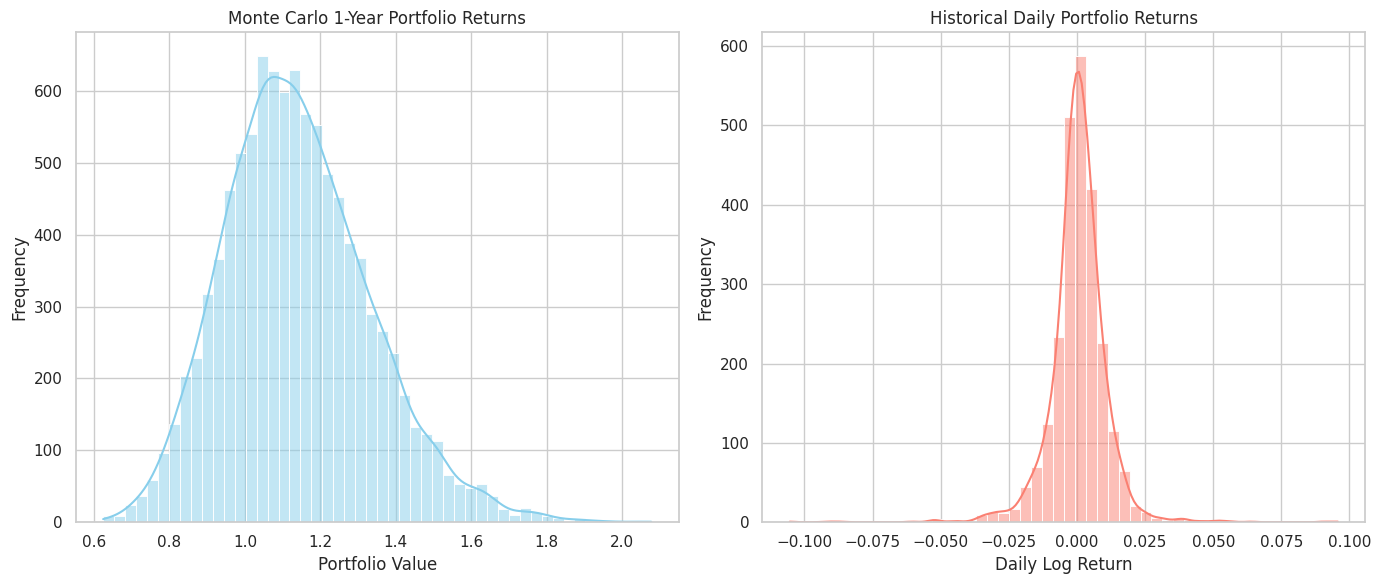

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for nice bell curves
sns.set(style="whitegrid")

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Monte Carlo 1-year simulated portfolio returns
sns.histplot(portfolio_sims, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Monte Carlo 1-Year Portfolio Returns")
axes[0].set_xlabel("Portfolio Value")
axes[0].set_ylabel("Frequency")

# Right plot: Historical daily portfolio returns
sns.histplot(historical_portfolio_daily, bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Historical Daily Portfolio Returns")
axes[1].set_xlabel("Daily Log Return")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


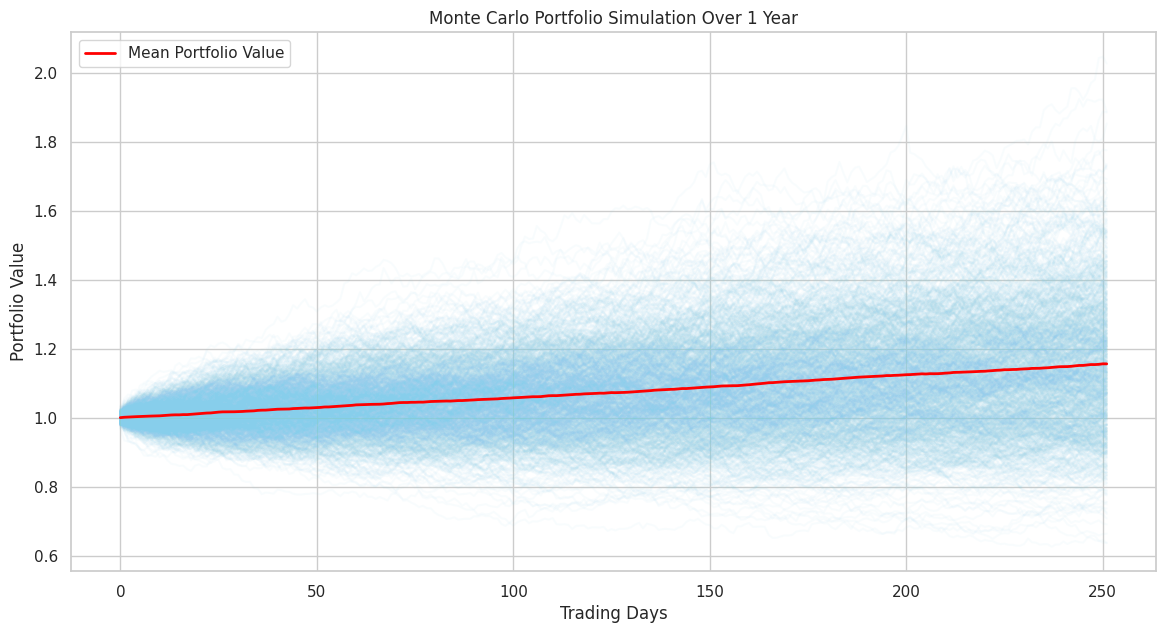

In [28]:
import matplotlib.pyplot as plt
import numpy as np

NUM_SIMULATIONS = 1000  # Plot fewer paths for readability
TRADING_DAYS = 252
initial_portfolio_value = 1.0

# Precompute Cholesky decomposition for correlated assets
chol_matrix = np.linalg.cholesky(cov_matrix)
num_assets = len(weights)

# Generate random paths
random_normals = np.random.normal(size=(NUM_SIMULATIONS, TRADING_DAYS, num_assets))
correlated_returns = random_normals @ chol_matrix.T
simulated_log_returns = correlated_returns + mean_returns

# Portfolio daily log returns
portfolio_daily_log = simulated_log_returns @ weights

# Convert to cumulative portfolio value over time
portfolio_paths = initial_portfolio_value * np.exp(np.cumsum(portfolio_daily_log, axis=1))

# --- Plot ---
plt.figure(figsize=(14,7))

# Plot all paths lightly
for i in range(NUM_SIMULATIONS):
    plt.plot(portfolio_paths[i], color='skyblue', alpha=0.05)

# Plot mean path
mean_path = portfolio_paths.mean(axis=0)
plt.plot(mean_path, color='red', linewidth=2, label='Mean Portfolio Value')

plt.title("Monte Carlo Portfolio Simulation Over 1 Year")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()
